# 05 · Memory & Microprocessor: from Address Bus to Fetch–Decode–Execute
**Course:** SLAO · Chapter III *Les mémoires* + Chapter 4 *Le microprocesseur* · ISG Tunis
**Covers:** memory organisation and sizing, CPU ↔ memory bus protocol, memory hierarchy, clock cycle, registers, the instruction cycle

---

## Objectives
1. Compute the **address width, address space and first/last address** of any memory (all slide exercises).
2. Model a memory with an **address decoder** and the read / write protocol (address bus, data bus, `L/E`, `OE`).
3. Explain the **memory hierarchy** and the SRAM / DRAM trade-off.
4. Build a small **CPU simulator** (registers PC, MAR, MDR, IR, R1–R3, flags Z N C V) with an **assembler**, and watch
   every micro-step of the FETCH → DECODE → EXECUTE cycle, including the course's worked example.

## Contents
1. Setup
2. Memory sizing (units, address width, address range)
3. Memory model with decoder and bus protocol
4. Memory hierarchy
5. Clock cycle
6. CPU simulator: ISA, assembler, ALU, instruction cycle
7. Chapter 4 worked example, reproduced micro-step by micro-step
8. A complete program: `LOAD → ADD → STORE → HALT`
9. A loop program and performance analysis

## 1 · Setup

In [1]:
from __future__ import annotations
import math
import re
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 70)

## 2 · Memory sizing

**Vocabulary (course notation).** A main memory (*mémoire centrale*, MC) is an array of **cells** (*cases*), each with a
unique **address**. All cells have the same size, the **cell size** (*T.C.M*), 1 octet = 8 bits unless stated otherwise.

| Quantity | Formula |
|---|---|
| Address width $n$ | number of bits needed to write an address |
| Address space $N$ | $N = 2^n$ cells, addresses $0 \dots N-1$ |
| Memory size (*T.M.C*) | $\text{T.M.C} = N \times \text{T.C.M}$ |
| First / last address | $n$ zeros / $n$ ones (write in hexadecimal) |

Units are binary: $1\text{K}=2^{10}$, $1\text{M}=2^{20}$, $1\text{G}=2^{30}$, $1\text{T}=2^{40}$; **1 octet (Ø) = 8 bits**.

In [2]:
PREFIX = {"": 1, "K": 2 ** 10, "M": 2 ** 20, "G": 2 ** 30, "T": 2 ** 40}


def parse_size(text: str) -> int:
    """'256 Kbits' / '128 KØ' / '128 MØ' / '4 octets' -> number of bits."""
    m = re.fullmatch(r"\s*(\d+)\s*([KMGT]?)\s*(bits?|octets?|o|Ø|B)\s*", text)
    if not m:
        raise ValueError(f"cannot parse {text!r}")
    amount, prefix, unit = m.groups()
    return int(amount) * PREFIX[prefix] * (1 if unit.startswith("bit") else 8)


def address_bits(tmc_bits: int, tcm_bits: int = 8) -> int:
    """n such that 2**n = T.M.C / T.C.M."""
    cells, remainder = divmod(tmc_bits, tcm_bits)
    if remainder or cells & (cells - 1):
        raise ValueError("T.M.C / T.C.M must be a power of two")
    return cells.bit_length() - 1


def address_range(n: int) -> tuple[str, str]:
    width = -(-n // 4)                                         # hexadecimal digits needed for n bits
    return format(0, f"0{width}X"), format(2 ** n - 1, f"0{width}X")


def memory_report(size: str, cell: str = "1 octet") -> dict:
    tmc, tcm = parse_size(size), parse_size(cell)
    n = address_bits(tmc, tcm)
    first, last = address_range(n)
    return {"memory": size, "cell size": cell, "cells N = 2^n": f"2^{n}", "n (address bits)": n,
            "first address": first + "h", "last address": last + "h"}

### Exercises from the slides

In [3]:
exercises = [
    ("256 Kbits", "1 octet", 15, "0000", "7FFF"),
    ("128 Kbits", "1 octet", 14, "0000", "3FFF"),
    ("128 KØ",    "1 octet", 17, "00000", "1FFFF"),
    ("128 Kbits", "2 octets", 13, "0000", "1FFF"),            # 'adressable par double octet' -> cell = 16 bits
]
rows = []
for size, cell, n_exp, first_exp, last_exp in exercises:
    r = memory_report(size, cell)
    assert (r["n (address bits)"], r["first address"], r["last address"]) == (n_exp, first_exp + "h", last_exp + "h")
    rows.append(r)
pd.DataFrame(rows)

,memory,cell size,cells N = 2^n,n (address bits),first address,last address
0,256 Kbits,1 octet,2^15,15,0000h,7FFFh
1,128 Kbits,1 octet,2^14,14,0000h,3FFFh
2,128 KØ,1 octet,2^17,17,00000h,1FFFFh
3,128 Kbits,2 octets,2^13,13,0000h,1FFFh


### Words versus cells (Example 2)

A processor works on **words** (16, 32, 64 bits). A word in memory (*mot mémoire*) may span several cells.
For a 32-bit processor and a 128 MØ memory with 1 Ø cells:

$$\text{number of words} = \frac{\text{T.M.C}}{\text{word size}} = \frac{2^{30}\ \text{bits}}{2^{5}\ \text{bits}} = 2^{25}$$

In [4]:
words = parse_size("128 MØ") // 32
assert words == 2 ** 25
print(f"128 MØ / 32-bit words = {words:,} words = 2^{words.bit_length() - 1}")

128 MØ / 32-bit words = 33,554,432 words = 2^25


## 3 · Memory model with address decoder and bus protocol

**Selecting a cell.** The processor's address register drives an **address decoder** (see notebook 04): for each address
exactly one select line is active, and that line enables one cell.

**Bus protocol** (from the course):

| Operation | Steps |
|---|---|
| **Read** | 1) address on address bus · 2) `L/E = 1` · 3) `OE = 1` (output enable) · 4) data bus value is latched in the data register |
| **Write** | 1) address on address bus · 2) data on data bus · 3) `L/E = 0` · 4) `OE = 1` |

In [5]:
def decoder_lines(address: int, n: int) -> list[int]:
    """One-hot select lines of an n -> 2**n address decoder."""
    return [int(i == address) for i in range(2 ** n)]


class MainMemory:
    """2**address_bits cells of `cell_bits` bits, accessed through the bus protocol."""

    def __init__(self, address_bits: int, cell_bits: int = 8):
        self.address_bits, self.cell_bits = address_bits, cell_bits
        self.cells = [0] * 2 ** address_bits
        self.bus_log: list[dict] = []

    def _check_address(self, address: int) -> None:
        if not 0 <= address < len(self.cells):
            raise IndexError(f"address {address} outside 0..{len(self.cells) - 1} ({self.address_bits} address bits)")

    def read(self, address: int, oe: int = 1):
        self._check_address(address)
        data = self.cells[address] if oe else None            # OE = 0: outputs disabled, nothing driven on the data bus
        self.bus_log.append({"operation": "READ", "address bus": address, "data bus": data, "L/E": 1, "OE": oe})
        return data

    def write(self, address: int, value: int, oe: int = 1) -> None:
        self._check_address(address)
        if not 0 <= value < 2 ** self.cell_bits:
            raise ValueError(f"{value} does not fit in a {self.cell_bits}-bit cell")
        if oe:
            self.cells[address] = value
        self.bus_log.append({"operation": "WRITE", "address bus": address, "data bus": value, "L/E": 0, "OE": oe})

    def read_word(self, address: int, n_cells: int) -> int:
        """Multi-cell word: only the FIRST address is given; the address register auto-increments.
        (Byte order is not specified by the course; here the first cell holds the most significant part.)"""
        word = 0
        for k in range(n_cells):
            word = (word << self.cell_bits) | self.read(address + k)
        return word

    def bus_table(self) -> pd.DataFrame:
        rows = []
        for e in self.bus_log:
            rows.append({**e,
                         "address bus": format(e["address bus"], f"0{self.address_bits}b"),
                         "data bus": "Z (high impedance)" if e["data bus"] is None
                                     else format(e["data bus"], f"0{self.cell_bits}b")})
        return pd.DataFrame(rows)


# 8 cells of 8 bits -> 3 address bits (the layout shown in the course)
ram = MainMemory(address_bits=3, cell_bits=8)
ram.write(0b010, 0b01100110)
print("address 010 -> select lines", decoder_lines(0b010, 3))
assert ram.read(0b010) == 0b01100110
assert ram.read(0b010, oe=0) is None                                     # OE = 0 -> nothing on the data bus
ram.bus_table()

address 010 -> select lines [0, 0, 1, 0, 0, 0, 0, 0]


,operation,address bus,data bus,L/E,OE
0,WRITE,010,01100110,0,1
1,READ,010,01100110,1,1
2,READ,010,Z (high impedance),1,0


In [6]:
# A 32-bit word stored in 4 consecutive 8-bit cells, read with ONE address (auto-increment)
ram = MainMemory(address_bits=3, cell_bits=8)
for k, byte in enumerate([0xCA, 0xFE, 0xBA, 0xBE]):
    ram.write(k, byte)
assert ram.read_word(0, 4) == 0xCAFEBABE
try:
    ram.read(8)                                                           # 3 address bits -> only 0..7 exist
except IndexError as e:
    print("bus error ->", e)

bus error -> address 8 outside 0..7 (3 address bits)


## 4 · Memory hierarchy

Memories are classified by three criteria: **access time**, **capacity** and **cost per bit**. These pull in opposite
directions, so a computer combines several levels: a small, fast, expensive one close to the processor and large, slow,
cheap ones further away.

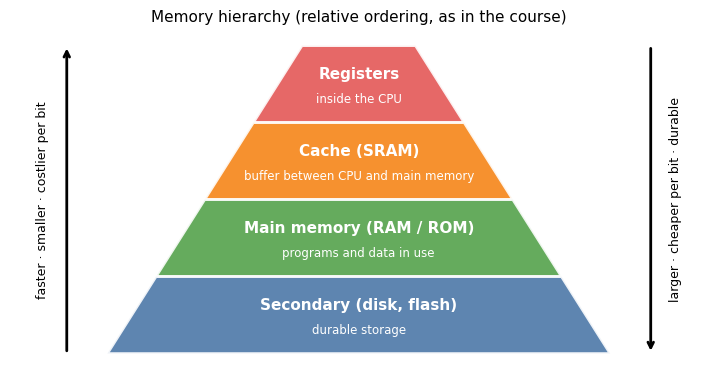

In [7]:
levels = [
    ("Registers",                "#e45756", "inside the CPU"),
    ("Cache (SRAM)",             "#f58518", "buffer between CPU and main memory"),
    ("Main memory (RAM / ROM)",  "#54a24b", "programs and data in use"),
    ("Secondary (disk, flash)",  "#4c78a8", "durable storage"),
]
fig, ax = plt.subplots(figsize=(9, 4.4))
step, base = 1.2, 1.4
for i, (name, colour, role) in enumerate(levels):
    top, bottom, y = base + i * step, base + (i + 1) * step, (len(levels) - 1 - i)
    ax.add_patch(Polygon([(-top / 2, y + 1), (top / 2, y + 1), (bottom / 2, y), (-bottom / 2, y)],
                         closed=True, fc=colour, ec="white", lw=2, alpha=0.9))
    ax.text(0, y + 0.62, name, ha="center", va="center", fontsize=11, color="white", fontweight="bold")
    ax.text(0, y + 0.3, role, ha="center", va="center", fontsize=8.5, color="white")
w = base + len(levels) * step
ax.annotate("", xy=(-w / 2 - 0.5, 4), xytext=(-w / 2 - 0.5, 0), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(-w / 2 - 0.8, 2, "faster · smaller · costlier per bit", rotation=90, ha="center", va="center", fontsize=9)
ax.annotate("", xy=(w / 2 + 0.5, 0), xytext=(w / 2 + 0.5, 4), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(w / 2 + 0.8, 2, "larger · cheaper per bit · durable", rotation=90, ha="center", va="center", fontsize=9)
ax.set_xlim(-w / 2 - 1.2, w / 2 + 1.2); ax.set_ylim(-0.2, 4.2); ax.axis("off")
ax.set_title("Memory hierarchy (relative ordering, as in the course)", fontsize=11)
plt.show()

In [8]:
pd.DataFrame([
    ("SRAM",   "one flip-flop per bit (2 NOR gates, 4 transistors) + 2 access transistors",
     "very fast", "expensive: 4 to 6 times more transistors than DRAM", "caches, registers"),
    ("DRAM",   "1 transistor + 1 capacitor per bit",
     "slower than SRAM", "cheap, high capacity, low power", "main memory"),
    ("ROM / PROM / EPROM", "programmed once or rarely rewritten",
     "read in normal operation", "non-volatile: keeps content without power", "boot code, fixed data"),
], columns=["type", "cell", "speed", "cost / density", "typical use"])

,type,cell,speed,cost / density,typical use
0,SRAM,"one flip-flop per bit (2 NOR gates, 4 transistors) + 2 access tran...",very fast,expensive: 4 to 6 times more transistors than DRAM,"caches, registers"
1,DRAM,1 transistor + 1 capacitor per bit,slower than SRAM,"cheap, high capacity, low power",main memory
2,ROM / PROM / EPROM,programmed once or rarely rewritten,read in normal operation,non-volatile: keeps content without power,"boot code, fixed data"


## 5 · Clock cycle

The processor is synchronised by a clock. The **cycle time** is the duration between two successive clock edges:

$$T_{\text{cycle}} = \frac{1}{f}$$

Do not confuse a *cycle* with an *instruction*: on most processors one instruction takes **several** cycles
(the simulator below makes this visible).

In [9]:
def cycle_time_ns(freq_hz: float) -> float:
    return 1e9 / freq_hz


pd.DataFrame([(f"{f / 1e9:g} GHz", cycle_time_ns(f)) for f in (1e9, 2e9, 3.2e9)], columns=["frequency", "cycle time (ns)"])
assert [cycle_time_ns(f) for f in (1e9, 2e9, 3.2e9)] == [1.0, 0.5, 0.3125]       # values worked in the chapter

## 6 · CPU simulator

### 6.1 Architecture

| Register | Role |
|---|---|
| **PC** (program counter) | address of the next instruction |
| **MAR** (memory address register) | address of the memory cell to access |
| **MDR** (memory data register, a.k.a. MBR) | data travelling to / from memory |
| **IR** (instruction register) | instruction being executed |
| **R1, R2, R3** | general registers (16 bits); the ALU result goes back to a register |
| **Flags Z N C V** | zero, negative, carry, overflow – set by the ALU, used by conditional jumps |

| Bus | Role | Direction |
|---|---|---|
| Address bus | carries the memory address | CPU → memory / I/O |
| Data bus | carries instructions and data | bidirectional |
| Control bus | `RD`, `WR`, `CLK`, `RESET`, `INT`, … | bidirectional / mixed |

### 6.2 Instruction set

The chapter fixes the **register–register format** `COP | R1 | R2` on 16 bits and the opcode `0001 = ADD`.
All other opcodes below are a **teaching extension** needed to run real programs; the memory is word-addressed (16-bit cells).

```
bits 15..12   11..8   7..4    3..0
   COP         R1      R2    (unused)        ADD R1,R2  ->  0001 0001 0010 0000  = 0x1120
```

`LOAD`, `STORE`, `JMP` and `JZ` occupy **two words**: the instruction word, then a 16-bit direct address.

In [10]:
OPCODES = {"ADD": 0b0001, "SUB": 0b0010, "AND": 0b0011, "OR": 0b0100, "XOR": 0b0101, "MOV": 0b0110,
           "LOAD": 0b0111, "STORE": 0b1000, "JMP": 0b1001, "JZ": 0b1010, "HALT": 0b1111}
MNEMONIC = {code_: name for name, code_ in OPCODES.items()}
ALU_OPS = {"ADD": "+", "SUB": "-", "AND": "&", "OR": "|", "XOR": "^"}
TWO_WORD = {"LOAD", "STORE", "JMP", "JZ"}
REG = {"R1": 1, "R2": 2, "R3": 3}
MASK = 0xFFFF


def encode(op: str, r1: int = 0, r2: int = 0) -> int:
    return (OPCODES[op] << 12) | (r1 << 8) | (r2 << 4)


assert encode("ADD", 1, 2) == 0b0001_0001_0010_0000          # the instruction of the chapter's worked example


def assemble(source: str, origin: int = 0):
    """Two-pass assembler. Returns (memory image {address: word}, symbol table, listing DataFrame)."""
    items, symbols, addr = [], {}, origin
    for raw in source.splitlines():                           # pass 1: assign addresses, collect labels
        line = raw.split(";")[0].strip()
        if not line:
            continue
        if ":" in line:
            label, line = (p.strip() for p in line.split(":", 1))
            symbols[label] = addr
        if line:
            items.append((addr, line))
            addr += 2 if line.split()[0].upper() in TWO_WORD else 1

    number = lambda tok: symbols[tok] if tok in symbols else int(tok, 0)
    image, listing = {}, []
    for addr, line in items:                                  # pass 2: encode
        op, _, rest = line.partition(" ")
        op, args = op.upper(), [a.strip() for a in rest.split(",")] if rest.strip() else []
        if op in ALU_OPS or op == "MOV":
            words = [encode(op, REG[args[0].upper()], REG[args[1].upper()])]
        elif op in ("LOAD", "STORE"):
            words = [encode(op, REG[args[0].upper()]), number(args[1])]
        elif op in ("JMP", "JZ"):
            words = [encode(op), number(args[0])]
        elif op == "HALT":
            words = [encode(op)]
        else:
            raise ValueError(f"unknown instruction {op!r}")
        for k, w in enumerate(words):
            image[addr + k] = w
        listing.append((addr, " ".join(f"{w:04X}" for w in words), line))
    return image, symbols, pd.DataFrame(listing, columns=["address", "machine code (hex)", "source"])


def alu(op: str, a: int, b: int):
    """16-bit ALU. Returns (result, flags). C = carry (ADD) or borrow (SUB); V = signed overflow."""
    if op == "ADD":
        raw = a + b
        res = raw & MASK
        carry, overflow = int(raw > MASK), int(((a ^ res) & (b ^ res) & 0x8000) != 0)
    elif op == "SUB":
        res = (a - b) & MASK
        carry, overflow = int(a < b), int(((a ^ b) & (a ^ res) & 0x8000) != 0)
    else:
        res = {"AND": a & b, "OR": a | b, "XOR": a ^ b}[op]
        carry = overflow = 0
    return res, {"Z": int(res == 0), "N": res >> 15, "C": carry, "V": overflow}

### 6.3 The CPU: every micro-step is recorded

One **micro-step = one clock cycle** in this teaching model. The micro-steps follow the chapter's detailed correction:

| Phase | Micro-steps |
|---|---|
| **FETCH** | `MAR ← PC` · `MDR ← mem[MAR]` (RD) · `IR ← MDR` · `PC ← PC + 1` |
| **DECODE** | the control unit identifies the opcode and operands |
| **EXECUTE** (ALU op) | read operands · ALU computes · flags updated · result written to R1 |

In [11]:
class CPU:
    def __init__(self, address_bits: int = 16):
        self.mem = MainMemory(address_bits, cell_bits=16)
        self.PC = self.MAR = self.MDR = self.IR = 0
        self.R = {1: 0, 2: 0, 3: 0}
        self.flags = {"Z": 0, "N": 0, "C": 0, "V": 0}
        self.halted = False
        self.trace: list[dict] = []
        self.instr_no, self.cycle = 0, 0
        self.instr_info: dict[int, dict] = {}

    # -- helpers ---------------------------------------------------------------------------------
    def load(self, image: dict[int, int]) -> None:
        for address, word in image.items():                 # program loading, not part of the traced bus activity
            self.mem.cells[address] = word

    def _log(self, phase: str, text: str, address=None, data=None, control: str = "") -> None:
        self.cycle += 1
        bus = "" if address is None else f"A={address}  D={'' if data is None else format(data, '04X')}  {control}"
        self.trace.append({
            "cycle": self.cycle, "instr": self.instr_no, "phase": phase, "micro-operation": text,
            "PC": self.PC, "MAR": self.MAR, "MDR": format(self.MDR, "04X"), "IR": format(self.IR, "04X"),
            "R1": format(self.R[1], "04X"), "R2": format(self.R[2], "04X"), "R3": format(self.R[3], "04X"),
            "ZNCV": "".join(str(self.flags[k]) for k in "ZNCV"), "bus": bus.strip(),
        })

    def _read_mem(self, phase: str, text: str) -> None:
        self.MDR = self.mem.read(self.MAR)
        self._log(phase, text, self.MAR, self.MDR, "RD")

    def _fetch_operand(self) -> int:
        """Fetch the address word that follows a 2-word instruction."""
        self.MAR = self.PC;               self._log("EXECUTE", "MAR ← PC   (address of the operand word)")
        self._read_mem("EXECUTE", "MDR ← mem[MAR]   (operand address)")
        self.PC = (self.PC + 1) & MASK;   self._log("EXECUTE", "PC ← PC + 1")
        return self.MDR

    # -- one full instruction cycle ---------------------------------------------------------------
    def step(self) -> None:
        if self.halted:
            return
        self.instr_no += 1
        self.instr_info[self.instr_no] = {"address": self.PC}

        # FETCH
        self.MAR = self.PC;                self._log("FETCH", "MAR ← PC")
        self._read_mem("FETCH", "MDR ← mem[MAR]")
        self.IR = self.MDR;                self._log("FETCH", "IR ← MDR")
        self.PC = (self.PC + 1) & MASK;    self._log("FETCH", "PC ← PC + 1")

        # DECODE
        opcode, r1, r2 = (self.IR >> 12) & 0xF, (self.IR >> 8) & 0xF, (self.IR >> 4) & 0xF
        if opcode not in MNEMONIC:
            raise ValueError(f"illegal opcode {opcode:04b} at address {self.instr_info[self.instr_no]['address']}")
        op = MNEMONIC[opcode]
        self.instr_info[self.instr_no]["text"] = op
        self._log("DECODE", f"CU decodes COP={opcode:04b} ({op}), R1={r1:04b}, R2={r2:04b}")

        # EXECUTE
        if op in ALU_OPS:
            a, b = self.R[r1], self.R[r2]
            self._log("EXECUTE", f"read R{r1}={a}, R{r2}={b} → ALU inputs")
            result, flags = alu(op, a, b)
            self._log("EXECUTE", f"ALU {op}: {a} {ALU_OPS[op]} {b} = {result}")
            self.flags = flags;            self._log("EXECUTE", "update flags Z N C V")
            self.R[r1] = result;           self._log("EXECUTE", f"R{r1} ← ALU result")
            self.instr_info[self.instr_no]["text"] = f"{op} R{r1}, R{r2}"
        elif op == "MOV":
            self._log("EXECUTE", f"read R{r2}")
            self.R[r1] = self.R[r2];       self._log("EXECUTE", f"R{r1} ← R{r2}")
            self.instr_info[self.instr_no]["text"] = f"MOV R{r1}, R{r2}"
        elif op == "LOAD":
            address = self._fetch_operand()
            self.MAR = self.MDR;           self._log("EXECUTE", "MAR ← MDR")
            self._read_mem("EXECUTE", "MDR ← mem[MAR]   (data)")
            self.R[r1] = self.MDR;         self._log("EXECUTE", f"R{r1} ← MDR")
            self.instr_info[self.instr_no]["text"] = f"LOAD R{r1}, {address}"
        elif op == "STORE":
            address = self._fetch_operand()
            self.MAR = self.MDR;           self._log("EXECUTE", "MAR ← MDR")
            self.MDR = self.R[r1];         self._log("EXECUTE", f"MDR ← R{r1}")
            self.mem.write(self.MAR, self.MDR)
            self._log("EXECUTE", "mem[MAR] ← MDR   (data)", self.MAR, self.MDR, "WR")
            self.instr_info[self.instr_no]["text"] = f"STORE R{r1}, {address}"
        elif op == "JMP":
            address = self._fetch_operand()
            self.PC = self.MDR;            self._log("EXECUTE", "PC ← MDR   (jump)")
            self.instr_info[self.instr_no]["text"] = f"JMP {address}"
        elif op == "JZ":
            address = self._fetch_operand()
            if self.flags["Z"]:
                self.PC = self.MDR;        self._log("EXECUTE", "Z = 1 → PC ← MDR   (jump taken)")
            else:
                self._log("EXECUTE", "Z = 0 → no jump")
            self.instr_info[self.instr_no]["text"] = f"JZ {address}"
        elif op == "HALT":
            self.halted = True;            self._log("EXECUTE", "HALT: stop the clock")

    def run(self, max_instructions: int = 10_000) -> None:
        while not self.halted:
            if self.instr_no >= max_instructions:
                raise RuntimeError("program did not halt")
            self.step()

    # -- reports ----------------------------------------------------------------------------------
    def trace_table(self, instr: int | None = None) -> pd.DataFrame:
        df = pd.DataFrame(self.trace)
        return df if instr is None else df[df.instr == instr].reset_index(drop=True)

    def cycles_per_instruction(self) -> pd.DataFrame:
        df = pd.DataFrame(self.trace)
        pivot = df.pivot_table(index="instr", columns="phase", values="cycle", aggfunc="count", fill_value=0)
        pivot = pivot[["FETCH", "DECODE", "EXECUTE"]]
        pivot["total"] = pivot.sum(axis=1)
        pivot.insert(0, "address", [self.instr_info[i]["address"] for i in pivot.index])
        pivot.insert(1, "instruction", [self.instr_info[i]["text"] for i in pivot.index])
        return pivot

## 7 · Chapter 4 worked example, micro-step by micro-step

**Setup (from the chapter):** instruction `ADD R1, R2` stored at address **120** (`0001 0001 0010 0000`), `PC = 120`, `R2 = 0005h`.
**Expected:** `R1 = 0007h`, `PC = 121`, `IR = MDR = 0001 0001 0010 0000`, `MAR = 120`.

> **Typo in the handout.** It states `R1 = 0010h (= 2)`, but `0010h` is **16**, not 2. The computed result 2 + 5 = 7 (`0007h`)
> requires `R1 = 0002h`, which is the value used here. (With `R1 = 0010h` the result would be `0015h` = 21.)

In [12]:
image, symbols, listing = assemble("ADD R1, R2", origin=120)
assert image == {120: 0b0001_0001_0010_0000}                # the assembler reproduces the chapter's machine word

cpu = CPU()
cpu.load(image)
cpu.PC, cpu.R[1], cpu.R[2] = 120, 0x0002, 0x0005
cpu.step()

cpu.trace_table()

,cycle,instr,phase,micro-operation,PC,MAR,MDR,IR,R1,R2,R3,ZNCV,bus
0,1,1,FETCH,MAR ← PC,120,120,0000,0000,0002,0005,0000,0000,
1,2,1,FETCH,MDR ← mem[MAR],120,120,1120,0000,0002,0005,0000,0000,A=120 D=1120 RD
2,3,1,FETCH,IR ← MDR,120,120,1120,1120,0002,0005,0000,0000,
3,4,1,FETCH,PC ← PC + 1,121,120,1120,1120,0002,0005,0000,0000,
4,5,1,DECODE,"CU decodes COP=0001 (ADD), R1=0001, R2=0010",121,120,1120,1120,0002,0005,0000,0000,
5,6,1,EXECUTE,"read R1=2, R2=5 → ALU inputs",121,120,1120,1120,0002,0005,0000,0000,
6,7,1,EXECUTE,ALU ADD: 2 + 5 = 7,121,120,1120,1120,0002,0005,0000,0000,
7,8,1,EXECUTE,update flags Z N C V,121,120,1120,1120,0002,0005,0000,0000,
8,9,1,EXECUTE,R1 ← ALU result,121,120,1120,1120,0007,0005,0000,0000,


In [13]:
final = pd.DataFrame({
    "register": ["PC", "R1", "R2", "IR", "MAR", "MDR"],
    "final value": [cpu.PC, f"{cpu.R[1]:04X}h = {cpu.R[1]}", f"{cpu.R[2]:04X}h = {cpu.R[2]}",
                    f"{cpu.IR:016b}", cpu.MAR, f"{cpu.MDR:016b}"],
    "chapter": ["121", "0007h (= 7)", "0005h (= 5)", "0001 0001 0010 0000", "120", "0001 0001 0010 0000"],
})
display(final)

assert (cpu.PC, cpu.R[1], cpu.R[2], cpu.MAR) == (121, 7, 5, 120)
assert cpu.IR == cpu.MDR == 0b0001_0001_0010_0000
assert cpu.flags == {"Z": 0, "N": 0, "C": 0, "V": 0}          # Z=0, N=0, C=0, V=0 as in the correction
phases = cpu.trace_table().phase.value_counts()
print("micro-steps:", dict(phases), "-> total", len(cpu.trace), "cycles for this one instruction")

,register,final value,chapter
0,PC,121,121
1,R1,0007h = 7,0007h (= 7)
2,R2,0005h = 5,0005h (= 5)
3,IR,0001000100100000,0001 0001 0010 0000
4,MAR,120,120
5,MDR,0001000100100000,0001 0001 0010 0000


micro-steps: {'FETCH': np.int64(4), 'EXECUTE': np.int64(4), 'DECODE': np.int64(1)} -> total 9 cycles for this one instruction


## 8 · A complete program

The chapter's example program, with the data it implies (`mem[1000] = 2`, `R2 = 5`):

```
LOAD  R1, 1000
ADD   R1, R2
STORE R1, 2000
HALT
```

In [14]:
program = """
        LOAD  R1, 1000      ; R1 <- mem[1000]
        ADD   R1, R2        ; R1 <- R1 + R2
        STORE R1, 2000      ; mem[2000] <- R1
        HALT
"""
image, symbols, listing = assemble(program, origin=120)
display(listing)

cpu = CPU()
cpu.load(image)
cpu.mem.cells[1000] = 2
cpu.R[2] = 5
cpu.PC = 120
cpu.run()

assert cpu.mem.cells[2000] == 7 and cpu.halted
print(f"mem[2000] = {cpu.mem.cells[2000]}   (2 + 5)    total cycles = {cpu.cycle}")
cycles = cpu.cycles_per_instruction()
cycles

,address,machine code (hex),source
0,120,7100 03E8,"LOAD R1, 1000"
1,122,1120,"ADD R1, R2"
2,123,8100 07D0,"STORE R1, 2000"
3,125,F000,HALT


mem[2000] = 7   (2 + 5)    total cycles = 37


phase,address,instruction,FETCH,DECODE,EXECUTE,total
instr,,,,,,
1,120,"LOAD R1, 1000",4,1,6,11
2,122,"ADD R1, R2",4,1,4,9
3,123,"STORE R1, 2000",4,1,6,11
4,125,HALT,4,1,1,6


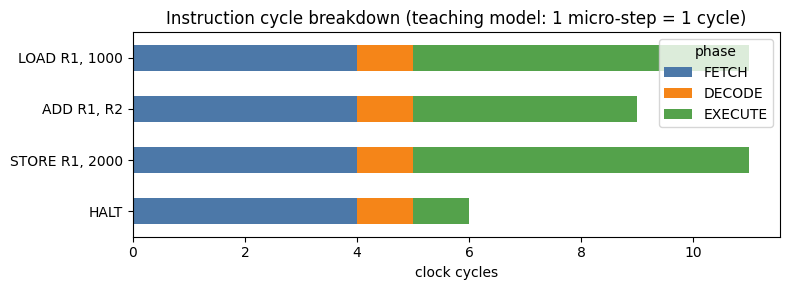

In [15]:
# Cycles per instruction, by phase (stacked): one instruction is NOT one cycle
ax = cycles.set_index("instruction")[["FETCH", "DECODE", "EXECUTE"]].plot.barh(
    stacked=True, figsize=(8, 3), color=["#4c78a8", "#f58518", "#54a24b"])
ax.invert_yaxis(); ax.set_xlabel("clock cycles"); ax.set_ylabel("")
ax.set_title("Instruction cycle breakdown (teaching model: 1 micro-step = 1 cycle)")
plt.tight_layout(); plt.show()

In [16]:
# Bus activity of the whole program: every memory access with address / data / control signals
bus = cpu.trace_table()
bus = bus[bus.bus != ""][["cycle", "instr", "phase", "micro-operation", "bus"]]
bus.reset_index(drop=True)

,cycle,instr,phase,micro-operation,bus
0,2,1,FETCH,MDR ← mem[MAR],A=120 D=7100 RD
1,7,1,EXECUTE,MDR ← mem[MAR] (operand address),A=121 D=03E8 RD
2,10,1,EXECUTE,MDR ← mem[MAR] (data),A=1000 D=0002 RD
3,13,2,FETCH,MDR ← mem[MAR],A=122 D=1120 RD
4,22,3,FETCH,MDR ← mem[MAR],A=123 D=8100 RD
5,27,3,EXECUTE,MDR ← mem[MAR] (operand address),A=124 D=07D0 RD
6,31,3,EXECUTE,mem[MAR] ← MDR (data),A=2000 D=0007 WR
7,33,4,FETCH,MDR ← mem[MAR],A=125 D=F000 RD


**Reading the bus trace.** Each instruction starts with a read at the address in `PC` (control line `RD`); `LOAD` adds
two more reads (operand address, then the data), `STORE` ends with a write (`WR`). This is the
"address on the address bus → `RD`/`WR` on the control bus → data on the data bus" sequence from Chapter 4.

## 9 · A loop program and performance analysis

Sum of 1 to 5 with a loop. `SUB` sets the **Z flag** when the counter reaches 0 and `JZ` tests it:

```
        LOAD  R2, 1002      ; counter = 5
        LOAD  R3, 1001      ; constant 1
loop:   ADD   R1, R2        ; sum += counter
        SUB   R2, R3        ; counter -= 1   (sets Z when it hits 0)
        JZ    done
        JMP   loop
done:   STORE R1, 2001
        HALT
```

In [17]:
loop_program = """
        LOAD  R2, 1002
        LOAD  R3, 1001
loop:   ADD   R1, R2
        SUB   R2, R3
        JZ    done
        JMP   loop
done:   STORE R1, 2001
        HALT
"""
image, symbols, listing = assemble(loop_program, origin=100)
print("labels:", symbols)
display(listing)

cpu = CPU()
cpu.load(image)
cpu.mem.cells[1001], cpu.mem.cells[1002] = 1, 5
cpu.PC = 100
cpu.run()

assert cpu.mem.cells[2001] == 15 == sum(range(1, 6))
print(f"mem[2001] = {cpu.mem.cells[2001]}   instructions executed = {cpu.instr_no}   clock cycles = {cpu.cycle}")

labels: {'loop': 104, 'done': 110}


,address,machine code (hex),source
0,100,7200 03EA,"LOAD R2, 1002"
1,102,7300 03E9,"LOAD R3, 1001"
2,104,1120,"ADD R1, R2"
3,105,2230,"SUB R2, R3"
4,106,A000 006E,JZ done
5,108,9000 0068,JMP loop
6,110,8100 07D1,"STORE R1, 2001"
7,112,F000,HALT


mem[2001] = 15   instructions executed = 23   clock cycles = 210


In [18]:
# Independent check of the cycle count: cost per instruction type, derived from the micro-step list in 6.3
COST = {"ADD": 9, "SUB": 9, "AND": 9, "OR": 9, "XOR": 9, "MOV": 7, "LOAD": 11, "STORE": 11, "JMP": 9, "JZ": 9, "HALT": 6}
per_instr = cpu.cycles_per_instruction()
expected = sum(COST[row.instruction.split()[0]] for row in per_instr.itertuples())
assert expected == cpu.cycle
print(f"cycle count confirmed independently: {expected}")

summary = per_instr.assign(op=per_instr.instruction.str.split().str[0]).groupby("op")[["total"]].agg(["count", "sum"])
summary.columns = ["times executed", "cycles"]
summary.sort_values("cycles", ascending=False)

cycle count confirmed independently: 210


,times executed,cycles
op,,
ADD,5,45
SUB,5,45
JZ,5,45
JMP,4,36
LOAD,2,22
STORE,1,11
HALT,1,6


In [19]:
# Execution time = cycles x cycle time, at the frequencies used in the chapter
pd.DataFrame([(f"{f / 1e9:g} GHz", cycle_time_ns(f), cpu.cycle * cycle_time_ns(f)) for f in (1e9, 2e9, 3.2e9)],
             columns=["frequency", "cycle time (ns)", f"time for {cpu.cycle} cycles (ns)"])

,frequency,cycle time (ns),time for 210 cycles (ns)
0,1 GHz,1.0000,210.000
1,2 GHz,0.5000,105.000
2,3.2 GHz,0.3125,65.625


## Summary

| Topic | Key formula / idea | Where |
|---|---|---|
| Address width | $2^n = \text{T.M.C} / \text{T.C.M}$ | `address_bits`, `memory_report` |
| First / last address | $n$ zeros / $n$ ones, in hexadecimal | `address_range` |
| Read / write | address bus + `L/E` + `OE` + data bus | `MainMemory` |
| Selecting a cell | address decoder, one-hot | `decoder_lines` |
| Cycle time | $T = 1/f$ | `cycle_time_ns` |
| Instruction cycle | FETCH → DECODE → EXECUTE, then repeat | `CPU.step` |
| 1 instruction ≠ 1 cycle | 9 cycles for `ADD`, 11 for `LOAD` / `STORE` in this model | `cycles_per_instruction` |

**Course map of the repository:** 01 numbers → 02 signed numbers & floats → 03 logic functions → 04 circuits → **05 memory & CPU**.